In [2]:
import pandas as pd

data = pd.read_csv('./data/train.csv')

In [3]:
pd.get_dummies(data['HomePlanet'], prefix='HomePlanet')

,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars
0,0,1,0
1,1,0,0
2,0,1,0
3,0,1,0
4,1,0,0
...,...,...,...
8688,0,1,0
8689,1,0,0
8690,1,0,0
8691,0,1,0


In [4]:
data = pd.read_csv('./data/train.csv')
# Add back in cabin once I have more time
data = data.drop(['PassengerId', 'Cabin', 'Name'], axis=1)
data = data.dropna()
data['HomePlanet'] = data['HomePlanet'].astype('category')
data['CryoSleep'] = data['CryoSleep'].astype('bool')
data['Destination'] = data['Destination'].astype('category')
data['VIP'] = data['VIP'].astype('bool')

data


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True
...,...,...,...,...,...,...,...,...,...,...,...
8688,Europa,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False
8689,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False
8690,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True
8691,Europa,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False


In [5]:
data.dtypes

HomePlanet      category
CryoSleep           bool
Destination     category
Age              float64
VIP                 bool
RoomService      float64
FoodCourt        float64
ShoppingMall     float64
Spa              float64
VRDeck           float64
Transported         bool
dtype: object

In [6]:
pd.get_dummies(data['HomePlanet'])

,Earth,Europa,Mars
0,0,1,0
1,1,0,0
2,0,1,0
3,0,1,0
4,1,0,0
...,...,...,...
8688,0,1,0
8689,1,0,0
8690,1,0,0
8691,0,1,0


In [7]:
import torch

class Dataset(torch.utils.data.Dataset):
  def __init__(self, df):
    self.home_planet = pd.get_dummies(df['HomePlanet'], prefix='HomePlanet')
    self.destination = pd.get_dummies(df['Destination'], prefix='Destination')

    self.vip = df['VIP']
    self.cryo_sleep = df['CryoSleep']

    self.age = df['Age']
    self.spending = df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']]

    self.y = df['Transported']
    
  def __len__(self):
    return len(self.vip)
    
  def __getitem__(self, idx):
    if isinstance(idx, torch.Tensor):
            idx = idx.tolist()

    # Only working on home planet right now ....
    # TODO fix this to give everything
    return [self.home_planet.iloc[idx].values, self.y.iloc[idx]] 
    
dataset = Dataset(data)

/Users/kyle/Work/projects/kaggle/env/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
from torch import nn

class Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.home_planet = nn.Sequential(
      nn.Linear(3, 3),
      nn.ReLU(),
      nn.Linear(3, 1)
    )

  def forward(self, x):
    x = self.home_planet(x)
    return x.squeeze()

In [16]:
pd.get_dummies(data, columns=['HomePlanet'])

,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars
0,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,0,1,0
1,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,1,0,0
2,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,0,1,0
3,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,0,1,0
4,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,False,0,1,0
8689,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,False,1,0,0
8690,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,True,1,0,0
8691,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,False,0,1,0


In [21]:
# Copy prior art to create 
class CSVDataset(torch.utils.data.Dataset):
  def __init__(self, csv):
    raw_data = pd.read_csv(csv)    
    # Add back in cabin once I have more time
    raw_data = raw_data.drop(['PassengerId', 'Cabin', 'Name'], axis=1)
    raw_data = raw_data.dropna()
    raw_data['HomePlanet'] = data['HomePlanet'].astype('category')
    raw_data['CryoSleep'] = data['CryoSleep'].astype('bool')
    raw_data['Destination'] = data['Destination'].astype('category')
    raw_data['VIP'] = data['VIP'].astype('bool')
    
    raw_data = pd.get_dummies(raw_data, columns=['HomePlanet', 'Destination'])
    
    self.y = raw_data['Transported']
    raw_data.drop(['Transported'], axis=1)
    self.x = raw_data
    
    
  def __len__(self):
    return len(self.x)
    
  def __getitem__(self, idx):
    return [self.x.iloc[idx].values, self.y.iloc[idx]] 
    


In [22]:
from torch.utils.data import DataLoader, random_split

dataset = CSVDataset('./data/train.csv')
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
trainset, testset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(trainset, batch_size=200, shuffle=True)
test_loader = DataLoader(testset, batch_size=200, shuffle=True)


In [ ]:
class Model2(nn.Module):
  def __init__(self):
    super.__init__()
    self.home_planet = nn.Sequential(
      nn.Linear(3, 3),
      nn.ReLU(),
      nn.Linear(3, 1)
    )
    self.destination = nn.Sequential(
      nn.Linear(3, 3),
      nn.ReLU(),
      nn.Linear(3, 1)
    )
  def forward(self, x):
    

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Root mean squared error
Training: 0.0915030120978075


ValueError: x and y must have same first dimension, but have shapes (700,) and (2800,)

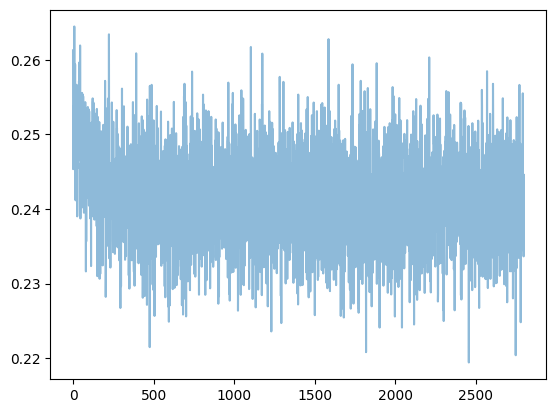

In [14]:
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

def train(epochs=100):
  model = Model()
  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), weight_decay=0.0001)

  # Sad days :(
  device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
  
  # Train the net
  loss_per_iter = []
  loss_per_batch = []
  for epoch in range(epochs):
    print("Epoch", epoch)

    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
      inputs = inputs.to(device)
      labels = labels.to(device)

      # Zero the parameter gradients
      optimizer.zero_grad()

      # Forward + backward + optimize
      outputs = model(inputs.float())
      loss = criterion(outputs, labels.float())
      loss.backward()
      optimizer.step()

      # Save loss to plot
      running_loss += loss.item()
      loss_per_iter.append(loss.item())

      loss_per_batch.append(running_loss / (i + 1))
      running_loss = 0.0

  # Comparing training to test
  dataiter = iter(test_loader)
  inputs, labels = dataiter.next()
  inputs = inputs.to(device)
  labels = labels.to(device)
  # outputs = net(inputs.float())
  print("Root mean squared error")
  print("Training:", np.sqrt(loss_per_batch[-1]))

  # Plot training loss curve
  plt.plot(np.arange(len(loss_per_iter)), loss_per_iter, "-", alpha=0.5, label="Loss per epoch")
  plt.plot(np.arange(len(loss_per_iter), step=4) + 3, loss_per_batch, ".-", label="Loss per mini-batch")
  plt.xlabel("Number of epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

train()

